In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:

binary_tree   = pd.read_excel('dataview/binary-tree.xlsx', sheet_name='InputMode')
multiple_tree = pd.read_excel('dataview/multiple-tree.xlsx', sheet_name='InputMode')
binary_tree['InputMode'] = binary_tree['InputMode'].replace({'edge': 'Edge', 'hierarchy': 'Text Tree'})
multiple_tree['InputMode'] = multiple_tree['InputMode'].replace({'edge': 'Edge', 'hierarchy': 'Text Tree'})
binary_tree, multiple_tree

(   InputMode       mean        std  count
 0       Edge  32.223036  34.897431    718
 1  Text Tree  34.613994  35.024556    696,
    InputMode       mean        std  count
 0       Edge  44.605916  32.051437    546
 1  Text Tree  44.536471  32.675251    544)

In [4]:
dfs = dict()
dfs['b&m'] = pd.DataFrame({'InputMode': ['Text Tree', 'Edge'], 'mean': [(binary_tree['mean'][1] + multiple_tree['mean'][1])/2, (binary_tree['mean'][0] + multiple_tree['mean'][0])/2]})
dfs['code'] = pd.read_excel('dataview/code.xlsx', sheet_name='CodeType')
dfs['paper'] = pd.DataFrame({'InputMode': ['XML', 'Plain Text'], 'mean': [33.9, 32.8]})
dfs['JSON'] = pd.DataFrame({'InputMode': ['Reasonable', 'Nonsense'], 'mean': [42.4, 37.7]})
dfs['code']['CodeType'] = dfs['code']['CodeType'].replace({'c++': 'C++', 'python': 'Python'})

dfs

{'b&m':    InputMode       mean
 0  Text Tree  39.575232
 1       Edge  38.414476,
 'code':   CodeType    mean        std  count
 0      C++  57.875  23.403032     40
 1   Python  53.175  21.737227     40,
 'paper':     InputMode  mean
 0         XML  33.9
 1  Plain Text  32.8,
 'JSON':     InputMode  mean
 0  Reasonable  42.4
 1    Nonsense  37.7}

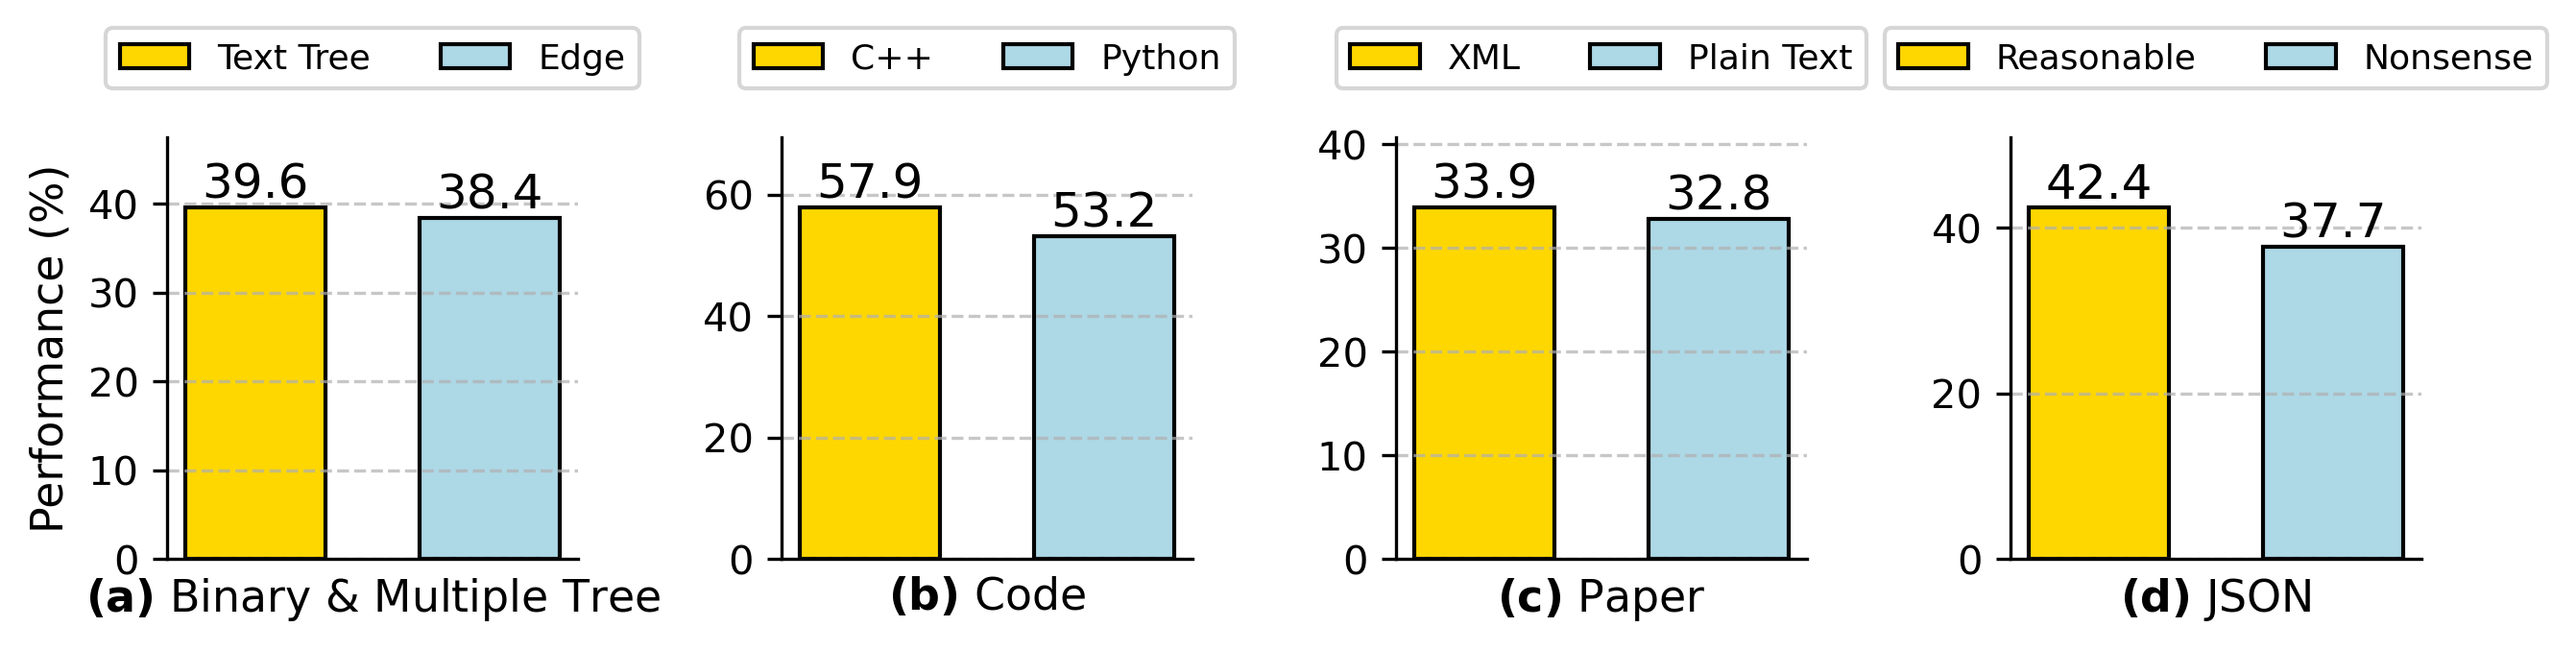

In [7]:

fig, axes = plt.subplots(1, 4, figsize=(9,2.5), dpi=300)
colors = ['gold', 'lightblue']
axes = axes.flatten()

titles = ['$\\bf{(a)}$ Binary & Multiple Tree', '$\\bf{(b)}$ Code', '$\\bf{(c)}$ Paper', '$\\bf{(d)}$ JSON']
legend_titles = ['Input Mode', 'Code Type', 'Input Mode', 'Input Mode']

for ax, (key, values), title, legend_title in zip(axes, dfs.items(), titles, legend_titles):
    x = [0, 1]
    bars = ax.bar(
        x, values['mean'], color=colors, label=values[legend_title.replace(' ', '')], 
        width=0.6, edgecolor='black'
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=12, color='black')

    ax.set_xticks([])
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylim(0, values['mean'].max() * 1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=2, fontsize=8.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Performance (%)', fontsize=11)
# Adjust layout and display plot
plt.tight_layout()
plt.savefig('../Images/input-mode.pdf')